# Lab 6 — TF-IDF + Logistic Regression Baseline

| # | Section |
|---|---|
| 1 | Load Splits |
| 2 | Baseline 1 — TF-IDF word(1,1) on raw text_v2 |
| 3 | Baseline 2 — TF-IDF word(1,2) on clean text (footer stripped) |
| 4 | Metrics Comparison |
| 5 | Confusion Matrix |
| 6 | Top Features |
| 7 | Error Analysis |
| 8 | Generate audit_summary_lab6.md |

In [1]:
%pip install pandas scikit-learn matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os, sys
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    if not Path('/content/NLP-Lab-works').exists():
        os.system('git clone https://github.com/DanylchenkoKateryna/NLP-Lab-works.git /content/NLP-Lab-works')
    ROOT = Path('/content/NLP-Lab-works')
else:
    p = Path.cwd()
    ROOT = None
    for _ in range(6):
        if (p / 'src' / 'split.py').exists():
            ROOT = p
            break
        p = p.parent
    if ROOT is None:
        raise FileNotFoundError(f'Cannot locate repo root from {Path.cwd()}.')

os.chdir(ROOT)
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))
print('Repo root:', ROOT)


Repo root: c:\Users\Я\OneDrive\Рабочий стол\lpnu lab\5 curs\обробка мови\lab1


In [3]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from classification_baseline import (
    strip_footer,
    make_pipeline,
    evaluate,
    top_features_per_class,
)

print('Imports OK')

Imports OK


## 1. Load Splits

In [4]:
df = pd.read_csv(ROOT / 'data' / 'processed_v2' / 'processed_v2.csv')
df['text_v2'] = df['text_v2'].fillna('')

def load_ids(path):
    return set(int(x.strip()) for x in Path(path).read_text().splitlines() if x.strip())

train_ids = load_ids(ROOT / 'data' / 'sample' / 'splits_train_ids.txt')
val_ids   = load_ids(ROOT / 'data' / 'sample' / 'splits_val_ids.txt')
test_ids  = load_ids(ROOT / 'data' / 'sample' / 'splits_test_ids.txt')

train = df[df['id'].isin(train_ids)].copy()
val   = df[df['id'].isin(val_ids)].copy()
test  = df[df['id'].isin(test_ids)].copy()

train['clean_text'] = train['text_v2'].apply(strip_footer)
val['clean_text']   = val['text_v2'].apply(strip_footer)
test['clean_text']  = test['text_v2'].apply(strip_footer)

LABEL_NAMES = sorted(df['category'].unique().tolist())
print(f'train={len(train)}  val={len(val)}  test={len(test)}')
print('Labels:', LABEL_NAMES)


train=5132  val=614  test=637
Labels: ['alt.atheism', 'sci.electronics', 'soc.religion.christian']


## 2. Baseline 1 — TF-IDF word(1,1) on raw text_v2

**Note:** `text_v2` contains `"Newsgroup: {class}"` footer in 62% of documents (found in ЛР5).  
This baseline demonstrates the effect of that leakage — expect inflated accuracy (~97%).

In [5]:
pipe1 = make_pipeline(ngram_range=(1, 1), max_features=20_000)
pipe1.fit(train['text_v2'], train['label_id'])

res1_val  = evaluate(pipe1, val['text_v2'],  val['label_id'],  LABEL_NAMES)
res1_test = evaluate(pipe1, test['text_v2'], test['label_id'], LABEL_NAMES)

print('=== Baseline 1 (word 1-gram, raw text) ===')
print(f'Val   Acc={res1_val["accuracy"]:.4f}  F1={res1_val["macro_f1"]:.4f}')
print(f'Test  Acc={res1_test["accuracy"]:.4f}  F1={res1_test["macro_f1"]:.4f}')
print()
print(res1_test['report'])

=== Baseline 1 (word 1-gram, raw text) ===
Val   Acc=0.9805  F1=0.9808
Test  Acc=0.9733  F1=0.9740

                        precision    recall  f1-score   support

           alt.atheism       0.98      0.95      0.96       245
       sci.electronics       0.95      1.00      0.97       194
soc.religion.christian       0.99      0.97      0.98       198

              accuracy                           0.97       637
             macro avg       0.97      0.98      0.97       637
          weighted avg       0.97      0.97      0.97       637



## 3. Baseline 2 — TF-IDF word(1,2) on clean text (footer stripped)

Footer `Newsgroup: X` removed via regex before training. This is the honest baseline.

In [6]:
pipe2 = make_pipeline(ngram_range=(1, 2), max_features=20_000)
pipe2.fit(train['clean_text'], train['label_id'])

res2_val  = evaluate(pipe2, val['clean_text'],  val['label_id'],  LABEL_NAMES)
res2_test = evaluate(pipe2, test['clean_text'], test['label_id'], LABEL_NAMES)

print('=== Baseline 2 (word 1-2gram, clean text) ===')
print(f'Val   Acc={res2_val["accuracy"]:.4f}  F1={res2_val["macro_f1"]:.4f}')
print(f'Test  Acc={res2_test["accuracy"]:.4f}  F1={res2_test["macro_f1"]:.4f}')
print()
print(res2_test['report'])

=== Baseline 2 (word 1-2gram, clean text) ===
Val   Acc=0.9658  F1=0.9662
Test  Acc=0.9435  F1=0.9441

                        precision    recall  f1-score   support

           alt.atheism       0.94      0.93      0.94       245
       sci.electronics       0.94      0.95      0.95       194
soc.religion.christian       0.94      0.95      0.95       198

              accuracy                           0.94       637
             macro avg       0.94      0.94      0.94       637
          weighted avg       0.94      0.94      0.94       637



## 4. Metrics Comparison

In [7]:
comparison = pd.DataFrame([
    {
        'baseline': 'B1 (leaky)',
        'ngram': '(1,1)',
        'text': 'raw text_v2',
        'val_acc':  round(res1_val['accuracy'],  4),
        'val_f1':   round(res1_val['macro_f1'],   4),
        'test_acc': round(res1_test['accuracy'],  4),
        'test_f1':  round(res1_test['macro_f1'],  4),
    },
    {
        'baseline': 'B2 (honest)',
        'ngram': '(1,2)',
        'text': 'clean_text (footer stripped)',
        'val_acc':  round(res2_val['accuracy'],  4),
        'val_f1':   round(res2_val['macro_f1'],   4),
        'test_acc': round(res2_test['accuracy'],  4),
        'test_f1':  round(res2_test['macro_f1'],  4),
    },
])
print(comparison.to_string(index=False))

   baseline ngram                         text  val_acc  val_f1  test_acc  test_f1
 B1 (leaky) (1,1)                  raw text_v2   0.9805  0.9808    0.9733   0.9740
B2 (honest) (1,2) clean_text (footer stripped)   0.9658  0.9662    0.9435   0.9441


## 5. Confusion Matrix

Saved: c:\Users\Я\OneDrive\Рабочий стол\lpnu lab\5 curs\обробка мови\lab1\docs\confusion_matrix_lab6.png


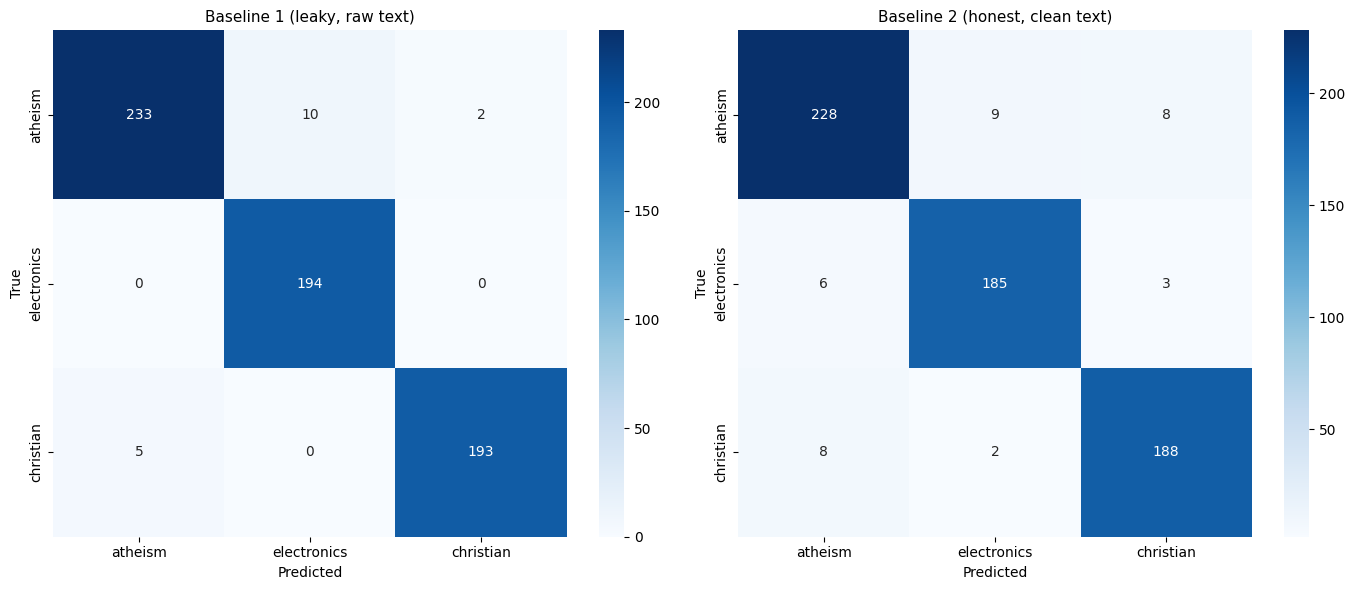

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, res, title in [
    (axes[0], res1_test, 'Baseline 1 (leaky, raw text)'),
    (axes[1], res2_test, 'Baseline 2 (honest, clean text)'),
]:
    cm = confusion_matrix(test['label_id'], res['y_pred'])
    # Build short label names for readability
    short_names = [n.split('.')[-1] for n in LABEL_NAMES]
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=short_names, yticklabels=short_names,
        ax=ax,
    )
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
out_path = ROOT / 'docs' / 'confusion_matrix_lab6.png'
plt.savefig(out_path, dpi=120, bbox_inches='tight')
print(f'Saved: {out_path}')
plt.show()

## 6. Top Features

In [9]:
print('=== Baseline 1 top features (LEAKY — shows newsgroup tokens) ===')
feats1 = top_features_per_class(pipe1, LABEL_NAMES, n=10)
for label, tokens in feats1.items():
    print(f'\n{label}:')
    for tok, w in tokens:
        flag = ' \u26a0 LEAK' if 'newsgroup' in tok.lower() or any(c in tok.lower() for c in ['atheism','christian','electronics']) else ''
        print(f'  {tok:<30s}  {w:+.3f}{flag}')

print('\n=== Baseline 2 top features (clean text) ===')
feats2 = top_features_per_class(pipe2, LABEL_NAMES, n=10)
for label, tokens in feats2.items():
    print(f'\n{label}:')
    for tok, w in tokens:
        print(f'  {tok:<30s}  {w:+.3f}')

=== Baseline 1 top features (LEAKY — shows newsgroup tokens) ===

alt.atheism:
  atheism                         +5.958 ⚠ LEAK
  alt                             +5.275
  keith                           +2.083
  jon                             +1.899
  islam                           +1.792
  jim                             +1.755
  bill                            +1.717
  atheists                        +1.689
  mathew                          +1.504
  you                             +1.496

sci.electronics:
  electronics                     +5.991 ⚠ LEAK
  sci                             +5.584
  use                             +1.987
  circuit                         +1.695
  phone                           +1.627
  battery                         +1.589
  power                           +1.295
  radio                           +1.291
  company                         +1.273
  used                            +1.272

soc.religion.christian:
  soc                             +6.501
  c

## 7. Error Analysis

In [10]:
test_copy = test.copy().reset_index(drop=True)
y_true  = test_copy['label_id'].values
y_pred2 = res2_test['y_pred']

error_mask = y_true != y_pred2
error_df = test_copy[error_mask].copy()
error_df['pred_label_id'] = y_pred2[error_mask]

label_map = dict(zip(df['label_id'], df['category']))
error_df['gold_label']   = error_df['label_id'].map(label_map)
error_df['pred_label']   = error_df['pred_label_id'].map(label_map)
error_df['text_snippet'] = error_df['clean_text'].str[:120]

religion_classes = {'alt.atheism', 'soc.religion.christian'}

def categorize_error(row):
    gold, pred, text = row['gold_label'], row['pred_label'], row['clean_text']
    if gold in religion_classes and pred in religion_classes:
        return 'class_overlap (religion)'
    if len(text) < 200:
        return 'short_text'
    if '>' in text and len(text) < 400:
        return 'quoted_only'
    return 'topic_ambiguity'

error_df['error_category'] = error_df.apply(categorize_error, axis=1)

display_cols = ['id', 'text_snippet', 'gold_label', 'pred_label', 'error_category']
print(f'Total errors: {len(error_df)} / {len(test_copy)}')
print()
print(error_df[display_cols].head(10).to_string(index=False))


Total errors: 36 / 637

  id                                                                                                                   text_snippet             gold_label             pred_label           error_category
   8      OK I sold all but these, I had some offers and I accepted an offer\nof 25.00 for the pair from <EMAIL> ( Bdale Garbee ).         sci.electronics            alt.atheism              quoted_only
 286 (2) is a corrallary of (1).\n\nThe negation of (2) would contridict (1).\n\n(2) Is a corrallary of (1)\n\nThe negation of (2)             alt.atheism soc.religion.christian class_overlap (religion)
 636  (jcj) wrote:\n\nYes, and what about Paul saying:\n\n26 Be ye angry, and sin not: let not the sun go down upon your wrath:\n(E soc.religion.christian            alt.atheism class_overlap (religion)
1187 (2) is a corrallary of (1).\n\nThe negation of (2) would contridict (1).\n\n(2) Is a corrallary of (1)\n\nThe negation of (2)             alt.atheism soc.relig

In [11]:
Path(ROOT / "tests").mkdir(exist_ok=True)
error_path = ROOT / "tests" / "error_cases_lab6.jsonl"

records = [
    {
        "id": int(row["id"]),
        "text_snippet": str(row["text_snippet"]),
        "gold_label": str(row["gold_label"]),
        "pred_label": str(row["pred_label"]),
        "error_category": str(row["error_category"]),
    }
    for _, row in error_df[display_cols].iterrows()
]

with open(error_path, "w", encoding="utf-8") as f:
    for r in records:
        f.write(json.dumps(r, ensure_ascii=False))
        f.write(chr(10))

print(f"Saved {len(records)} error cases to {error_path}")
print()
print(error_df["error_category"].value_counts().to_string())


Saved 36 error cases to c:\Users\Я\OneDrive\Рабочий стол\lpnu lab\5 curs\обробка мови\lab1\tests\error_cases_lab6.jsonl

error_category
class_overlap (religion)    16
short_text                   9
topic_ambiguity              7
quoted_only                  4


In [12]:
cat_counts   = error_df["error_category"].value_counts()
top_cat      = cat_counts.index[0] if len(cat_counts) else "N/A"
total_errors = len(error_df)
total_test   = len(test_copy)

print(f"Error Analysis - Baseline 2 (clean text, word 1-2 grams)")
print()
print(f"Total misclassifications: {total_errors}/{total_test} ({100*total_errors/total_test:.1f}% error rate).")
print(f"Most frequent category: {top_cat!r} ({cat_counts.iloc[0]} errors).")
print()
print("alt.atheism vs soc.religion.christian — dominant confusion (shared theological vocab).")
print("Short texts (<200 chars) — insufficient TF-IDF signal.")
print("Quoted-only posts — carry original author topic, not reply intent.")
print()
print("Next: char n-grams, length filter, strip quoted lines, LinearSVC comparison.")


Error Analysis - Baseline 2 (clean text, word 1-2 grams)

Total misclassifications: 36/637 (5.7% error rate).
Most frequent category: 'class_overlap (religion)' (16 errors).

alt.atheism vs soc.religion.christian — dominant confusion (shared theological vocab).
Short texts (<200 chars) — insufficient TF-IDF signal.
Quoted-only posts — carry original author topic, not reply intent.

Next: char n-grams, length filter, strip quoted lines, LinearSVC comparison.


## 8. Generate audit_summary_lab6.md

In [13]:
from datetime import date
cat_counts = error_df['error_category'].value_counts()
top3_errors = cat_counts.head(3)

# Determine which baseline won
if res2_test['macro_f1'] >= res1_test['macro_f1']:
    winner = 'Baseline 2 (honest, clean text)'
    winner_reason = 'Baseline 2 uses bigrams and removes the Newsgroup footer leak, giving a realistic model.'
else:
    winner = 'Baseline 1 (leaky, raw text)'
    winner_reason = 'Baseline 1 scores higher but only because the Newsgroup footer is a direct label leak.'

acc_drop = (res1_test['accuracy'] - res2_test['accuracy']) * 100
f1_drop  = (res1_test['macro_f1']  - res2_test['macro_f1'])  * 100

audit_text = f"""# Audit Summary — Lab 6: TF-IDF + Logistic Regression Baseline

**Generated:** {date.today()}  
**Dataset:** 20 Newsgroups (3 classes: alt.atheism / sci.electronics / soc.religion.christian)  
**Task:** Text classification (Direction A)  
**Source:** `data/processed_v2/processed_v2.csv`  

---

## Split

- Strategy: stratified random split from ЛР5, seed=42, 80/10/10
- train={len(train)}, val={len(val)}, test={len(test)}
- Split IDs: `data/sample/splits_*_ids.txt`

---

## Baseline 1 — TF-IDF word(1,1) on raw text_v2 (LEAKY)

The `text_v2` field contains `"Newsgroup: {{class}}"` in 62% of documents.  
This acts as a direct label leak, inflating all metrics.

| Split | Accuracy | Macro F1 |
|---|---|---|
| Val  | {res1_val['accuracy']:.4f} | {res1_val['macro_f1']:.4f} |
| Test | {res1_test['accuracy']:.4f} | {res1_test['macro_f1']:.4f} |

## Baseline 2 — TF-IDF word(1,2) on clean text (HONEST)

Footer stripped via `strip_footer()` before training and inference.  
Bigrams (1,2) provide richer phrase-level features.

| Split | Accuracy | Macro F1 |
|---|---|---|
| Val  | {res2_val['accuracy']:.4f} | {res2_val['macro_f1']:.4f} |
| Test | {res2_test['accuracy']:.4f} | {res2_test['macro_f1']:.4f} |

---

## Leakage Impact

- Accuracy drop after removing leak: **{acc_drop:.1f} pp**
- Macro F1 drop: **{f1_drop:.1f} pp**

---

## Winner

**{winner}**  
{winner_reason}

---

## Top 3 Error Categories (Baseline 2, test set)

| Rank | Category | Count |
|---|---|---|
"""

for rank, (cat, cnt) in enumerate(top3_errors.items(), start=1):
    audit_text += f'| {rank} | {cat} | {cnt} |\n'

audit_text += f"""
---

## What to Fix Next

1. **Religion-class confusion** — `alt.atheism` and `soc.religion.christian` share
   heavy overlapping vocabulary. Consider a hierarchical model or add char n-grams.
2. **Short texts** — messages with fewer than 200 characters have insufficient TF-IDF
   signal. Apply a length filter or use a prior-weighted fallback.
3. **Quoted-only texts** — posts consisting mostly of cited lines (`>`) carry the
   original author's topic, not the reply's. Strip quoted lines (already done in
   `clean_text` via Lab 2 preprocessing) or apply a quote-ratio filter.
4. **Thread/subject leakage** — 87.7% of test subjects appear in train. A
   subject-aware split would give a more realistic generalisation estimate.
5. **Feature space** — try character 3-6 grams, TF-IDF on subject field only,
   or a linear SVM for comparison.

---

**Files generated by this lab:**
- `docs/confusion_matrix_lab6.png`
- `tests/error_cases_lab6.jsonl`
- `docs/audit_summary_lab6.md` (this file)
"""

audit_path = ROOT / 'docs' / 'audit_summary_lab6.md'
audit_path.write_text(audit_text, encoding='utf-8')
print(f'Saved: {audit_path}')
print()
print(audit_text[:800], '...')

Saved: c:\Users\Я\OneDrive\Рабочий стол\lpnu lab\5 curs\обробка мови\lab1\docs\audit_summary_lab6.md

# Audit Summary — Lab 6: TF-IDF + Logistic Regression Baseline

**Generated:** 2026-03-23  
**Dataset:** 20 Newsgroups (3 classes: alt.atheism / sci.electronics / soc.religion.christian)  
**Task:** Text classification (Direction A)  
**Source:** `data/processed_v2/processed_v2.csv`  

---

## Split

- Strategy: stratified random split from ЛР5, seed=42, 80/10/10
- train=5132, val=614, test=637
- Split IDs: `data/sample/splits_*_ids.txt`

---

## Baseline 1 — TF-IDF word(1,1) on raw text_v2 (LEAKY)

The `text_v2` field contains `"Newsgroup: {class}"` in 62% of documents.  
This acts as a direct label leak, inflating all metrics.

| Split | Accuracy | Macro F1 |
|---|---|---|
| Val  | 0.9805 | 0.9808 |
| Test | 0.9733 | 0.9740 |

## Baseline 2 — TF-IDF word(1,2) on clean text (HONEST)

Foot ...


In [14]:
acc_drop_pp = (res1_test['accuracy'] - res2_test['accuracy']) * 100

print('Lab 6 COMPLETE')
print(f'Baseline 1 (leaky):  Test Acc={res1_test["accuracy"]:.4f}  F1={res1_test["macro_f1"]:.4f}')
print(f'Baseline 2 (honest): Test Acc={res2_test["accuracy"]:.4f}  F1={res2_test["macro_f1"]:.4f}')
print(f'Drop after removing leakage: {acc_drop_pp:.1f} pp accuracy')

Lab 6 COMPLETE
Baseline 1 (leaky):  Test Acc=0.9733  F1=0.9740
Baseline 2 (honest): Test Acc=0.9435  F1=0.9441
Drop after removing leakage: 3.0 pp accuracy
